This notebook calculated the results from the PBT Young dataset

In [88]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt


# 1) Preprocessing: detrend + gentle low-pass + band-pass + optional z-score
def preprocess_signal(ts: np.ndarray,
                      fs: float = 100.0,
                      low_lp: float = 10.0,
                      low_bp: float = 0.1,
                      high_bp: float = 5.0,
                      do_zscore: bool = False) -> np.ndarray:
    """
    Preprocess a COM time series (e.g. ML-COM in mm).

    Steps:
      1) Remove linear trend.
      2) Apply a gentle low-pass at `low_lp` Hz to remove >10 Hz noise.
      3) Apply a band-pass between `low_bp`–`high_bp` Hz to keep step‐frequency content.
      4) Optionally zero-mean and unit-variance (z-score).

    Inputs:
      ts       : 1D numpy array of COM values (in mm).
      fs       : Sampling frequency (Hz), default 100 Hz.
      low_lp   : Cutoff for low-pass filter (Hz), default 10 Hz.
      low_bp   : Lower cutoff for band-pass (Hz), default 0.1 Hz.
      high_bp  : Upper cutoff for band-pass (Hz), default 5 Hz.
      do_zscore: If True, z-score the final output.

    Returns:
      ts_out: Preprocessed 1D array, same length as input.
    """
    # 1) Detrend
    ts_dt = detrend(ts)

    # 2) Gentle low-pass at low_lp Hz
    nyq = fs / 2.0
    b_lp, a_lp = butter(N=4, Wn=(low_lp / nyq), btype='low')
    ts_lp = filtfilt(b_lp, a_lp, ts_dt)

    # 3) Band-pass from low_bp to high_bp Hz
    b_bp, a_bp = butter(N=4, Wn=[low_bp / nyq, high_bp / nyq], btype='bandpass')
    ts_bp = filtfilt(b_bp, a_bp, ts_lp)

    # 4) Optional z-score
    if do_zscore:
        ts_out = (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)
    else:
        ts_out = ts_bp

    return ts_out


import numpy as np

def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 10) -> float:
    # (a toy implementation just to make the code run)
    x = ts[:-lag]
    y = ts[lag:]
    # Use a tiny 2×2 histogram for speed, but we only care about τ_max here.
    hist2d, _, _ = np.histogram2d(x, y, bins=[np.linspace(ts.min(), ts.max(), bins+1)]*2)
    p_xy = hist2d / np.sum(hist2d)
    p_x = np.sum(p_xy, axis=1)
    p_y = np.sum(p_xy, axis=0)
    mask = p_xy > 0
    return np.sum(p_xy[mask] * np.log(p_xy[mask] / (p_x[:, None] * p_y[None, :])[mask]))


def optimal_lag(ts: np.ndarray,
                fs: float = 100.0,
                max_lag: int = 50,
                bins: int = 10) -> int:
    # 1) compute AMI(1…max_lag)
    ami_vals = np.empty(max_lag)
    for τ in range(1, max_lag + 1):
        ami_vals[τ-1] = average_mutual_information(ts, τ, bins)

    ami1 = ami_vals[0]
    lags = np.arange(1, max_lag + 1)

    # Compute τ_max = floor(0.20 * fs)
    τ_max = min(max_lag, int(0.20 * fs))
    print(f"DEBUG: fs = {fs}, 0.20*fs = {0.20 * fs}, int(0.20*fs) = {int(0.20 * fs)}, τ_max = {τ_max}")

    # 2) look for first strict local minimum up to τ_max
    if τ_max >= 3:
        for i in range(1, τ_max - 1):
            if (ami_vals[i] < ami_vals[i - 1]) and (ami_vals[i] < ami_vals[i + 1]):
                return i+1

    # 3) fallback #1: first τ ≤ τ_max where AMI(τ) ≤ AMI(1)/e
    threshold = ami1 / np.e
    for i in range(τ_max):
        if ami_vals[i] <= threshold:
            return i + 1

    # 4) fallback #2: global minimum
    return int(np.argmin(ami_vals) + 1)



# 4) Compute FNN% using Abarbanel’s two‐threshold method
def compute_fnn_percentage(ts: np.ndarray,
                           lag: int,
                           max_dim: int = 15,
                           Rtol: float = 0.15,
                           Atol_frac: float = 0.15) -> (np.ndarray, np.ndarray):
    """
    Compute the fraction of False Nearest Neighbors (FNN%) for embedding dims m=1…max_dim,
    using both:
      (1) Relative‐increase test: (R_{m+1} - R_m) / R_m > Rtol
      (2) Absolute‐scale test: R_{m+1} > Atol = Atol_frac * std(ts)

    Inputs:
      ts        : 1D time series.
      lag       : chosen embedding delay (samples).
      max_dim   : maximum embedding dimension to evaluate.
      Rtol      : relative distance threshold (default 0.15).
      Atol_frac : fraction of std(ts) for absolute threshold (default 0.15).

    Returns:
      dims     : array([1,2,…,max_dim])
      fnn_perc : length‐max_dim array of false‐neighbor percentages for each m.
    """
    N = len(ts)
    dims = np.arange(1, max_dim + 1)
    fnn_perc = np.zeros_like(dims, dtype=float)
    A_tol = Atol_frac * np.std(ts)

    for idx, m in enumerate(dims):
        M = N - m * lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break

        # Build m‐dimensional delay‐vectors of length M
        embedded_m = np.vstack([ts[i*lag : i*lag + M] for i in range(m)]).T

        false_count = 0
        total_count = 0
        exclusion = m * lag

        for i in range(M):
            # Distances in m‐D
            diffs = embedded_m - embedded_m[i]
            dists = np.linalg.norm(diffs, axis=1)
            dists[i] = np.inf  # exclude self
            start = max(0, i - exclusion)
            end   = min(M, i + exclusion + 1)
            dists[start:end] = np.inf  # exclude temporally close

            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue

            R_m = dists[j]

            # Compute (m+1)‐D distance if valid
            if (i + m*lag) >= N or (j + m*lag) >= N:
                # Cannot form (m+1)-D, skip
                continue

            coord_i_mp1 = ts[i + m*lag]
            coord_j_mp1 = ts[j + m*lag]
            R_mp1 = np.sqrt(R_m**2 + (coord_i_mp1 - coord_j_mp1)**2)

            # If either test fails → false neighbor
            if ((R_mp1 - R_m)/ (R_m + 1e-12) > Rtol) or (R_mp1 > A_tol):
                false_count += 1
            total_count += 1

        fnn_perc[idx] = false_count / total_count if total_count else np.nan

    return dims, fnn_perc


# 5) Optimal embedding dimension by “elbow” (max|2nd difference|)
def optimal_embedding_dimension(ts: np.ndarray,
                                lag: int,
                                max_dim: int = 15,
                                Rtol: float = 0.15,
                                Atol_frac: float = 0.15) -> int:
    """
    Choose embedding dimension m by finding the 'elbow' in the FNN% vs. m curve
    (largest absolute second‐difference). Falls back to max_dim if no clear elbow.

    Inputs:
      ts        : 1D time series.
      lag       : chosen embedding delay.
      max_dim   : maximum dimension to test (default 15).
      Rtol      : relative threshold for FNN.
      Atol_frac : absolute‐scale fraction for FNN.

    Returns:
      m_elbow   : chosen embedding dimension (1…max_dim).
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, Rtol, Atol_frac)

    # If not enough points or all NaN, return max_dim
    if len(dims) < 3 or np.all(np.isnan(fnn)):
        return max_dim

    second_diff = np.diff(fnn, n=2)  # length = max_dim − 2

    if np.all(np.isnan(second_diff)) or np.allclose(second_diff, 0, equal_nan=True):
        return max_dim

    i_elbow = int(np.nanargmax(np.abs(second_diff)))
    m_elbow = i_elbow + 2  # because second_diff[i] corresponds to m = i+2

    # Clamp
    if m_elbow < 1:
        return 1
    if m_elbow > max_dim:
        return max_dim
    return m_elbow


# 6) Rosenstein’s short‐term Lyapunov exponent λ*
# def compute_lyapunov_exponent(ts: np.ndarray,
#                               emb_dim: int,
#                               lag: int,
#                               fs: float = 100.0,
#                               max_time: float = 5.0,
#                               n_bins: int = 50) -> float:
#     """
#     Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors:
#       1) Reconstruct phase‐space in dimension emb_dim with delay=lag.
#       2) For each point, find its nearest neighbor (excluding Theiler window).
#       3) Track distance d(k) = || X[i+k] - X[j+k] || for k=1…k_max (up to max_time).
#       4) Bin (t = k/fs) vs. log(dist) into n_bins over [0, max_time].
#       5) Fit a straight line to ⟨ln d(t)⟩ vs. t over [0.10, 0.50] s. Slope = λ*.

#     Inputs:
#       ts       : 1D time series.
#       emb_dim  : embedding dimension m.
#       lag      : embedding delay τ (samples).
#       fs       : sampling frequency (Hz).
#       max_time : maximum evolution time for divergence (s).
#       n_bins   : number of equal‐width bins between 0…max_time.

#     Returns:
#       slope    : short‐term Lyapunov exponent λ* (1/s). NaN if insufficient data.
#     """
#     N = len(ts)
#     M = N - (emb_dim - 1) * lag
#     if M <= 0:
#         return np.nan

#     # Reconstruct m-dim delay vectors
#     embedded = np.vstack([ts[i*lag : i*lag + M] for i in range(emb_dim)]).T
#     min_sep = emb_dim * lag
#     divergence = []

#     for i in range(M):
#         dists = np.linalg.norm(embedded - embedded[i], axis=1)
#         dists[i] = np.inf
#         dists[max(0, i - min_sep) : i + min_sep] = np.inf
#         j = np.argmin(dists)
#         if dists[j] == np.inf:
#             continue

#         k_max = min(M - i, M - j, int(max_time * fs))
#         for k in range(1, k_max):
#             d = np.linalg.norm(embedded[i + k] - embedded[j + k])
#             if d > 0:
#                 divergence.append((k / fs, np.log(d)))

#     if not divergence:
#         return np.nan

#     data = np.array(divergence)  # shape (num_pairs, 2)
#     times = data[:, 0]
#     logs = data[:, 1]

#     # Bin into n_bins between 0…max_time
#     bin_edges = np.linspace(0, max_time, n_bins + 1)
#     centers = []
#     means = []
#     for b in range(len(bin_edges) - 1):
#         mask = (times >= bin_edges[b]) & (times < bin_edges[b + 1])
#         if mask.any():
#             centers.append((bin_edges[b] + bin_edges[b + 1]) / 2)
#             means.append(logs[mask].mean())
#     centers = np.array(centers)
#     means = np.array(means)

#     # Plot divergence curve for inspection
#     plt.figure(figsize=(5, 3))
#     plt.plot(centers, means, 'o-')
#     plt.axvline(0.12, color='r', linestyle='--', label='0.00 s')
#     plt.axvline(0.50, color='r', linestyle='--', label='0.5 s')
#     plt.xlabel('Time (s)')
#     plt.ylabel('Average ln(distance)')
#     plt.title('Divergence curve')
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Fit only over [0.10, 0.50] s
#     fit_mask = (centers >= 0.12) & (centers <= 0.32)
#     if fit_mask.sum() < 2:
#         return np.nan

#     slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
#     return slope

def compute_lyapunov_exponent(ts: np.ndarray, emb_dim: int, lag: int,
                              fs: float = 100.0, max_time: float = 5.0) -> float:
    """
    Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors.
    Fit ⟨ln d(t)⟩ vs. t over 0.1–0.5 s.
    """
    N = len(ts)
    M = N - (emb_dim - 1) * lag
    if M <= 0:
        return np.nan

    embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i - min_sep) : i + min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i + k] - embedded[j + k])
            if d > 0:
                divergence.append((k / fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:, 0], data[:, 1]

    # Bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins) - 1):
        mask = (times >= bins[b]) & (times < bins[b + 1])
        if mask.any():
            centers.append((bins[b] + bins[b + 1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # Plot divergence curve for inspection
    plt.figure()
    plt.plot(centers, means, 'o-')
    plt.axvline(0.1, color='r', linestyle='--', label='0.1 s')
    plt.axvline(0.5, color='r', linestyle='--', label='0.5 s')
    plt.xlabel('Time (s)')
    plt.ylabel('Average ln(distance)')
    plt.title('Divergence curve')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Fit only over 0.1–0.5 s
    fit_mask = (centers >= 0.1) & (centers <= 0.5)
    if fit_mask.sum() < 2:
        return np.nan

    slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    return slope





thsi is the correct ntoebooks which works perfectly for the calucation

In [92]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt


# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(ts: np.ndarray,
                   fs: float = 100.0,
                   low_bp: float = 0.1,
                   high_bp: float = 5.0,
                   low_lp: float = 10.0,
                   do_zscore: bool = False) -> np.ndarray:
    """
    Preprocess a mediolateral COM (in mm) time series.
    
    Steps:
      1) Remove linear trend (detrend).
      2) Apply a gentle low-pass at `low_lp` Hz to remove >10 Hz noise.
      3) Apply a band-pass between `low_bp`–`high_bp` Hz to keep step frequency.
      4) Optionally zero-mean & unit-variance (z-score).
    
    Inputs:
      ts      : 1D np.ndarray of COM_x values in millimeters.
      fs      : Sampling frequency (default 100 Hz).
      low_bp  : Lower cutoff for band-pass (default 0.1 Hz).
      high_bp : Upper cutoff for band-pass (default 5.0 Hz).
      low_lp  : Cutoff for low-pass (default 10.0 Hz).
      do_zscore : If True, z-score the final output.
    
    Returns:
      ts_out  : Preprocessed 1D array, same length as input.
    """
    # 1) Detrend
    ts_dt = detrend(ts)

    # 2) Gentle low-pass at low_lp Hz
    nyq = fs / 2.0
    b_lp, a_lp = butter(N=4, Wn=(low_lp/nyq), btype='low')
    ts_lp = filtfilt(b_lp, a_lp, ts_dt)

    # 3) Band-pass from low_bp to high_bp Hz
    b_bp, a_bp = butter(N=4, Wn=[low_bp/nyq, high_bp/nyq], btype='bandpass')
    ts_bp = filtfilt(b_bp, a_bp, ts_lp)

    # 4) (Optional) Z-score
    if do_zscore:
        ts_out = (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)
    else:
        ts_out = ts_bp

    return ts_out



# 2) Average Mutual Information with quantile bins
def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 64) -> float:
    """
    Compute AMI I(lag) between x(t) and x(t+lag) using equal‐occupancy bins.
    """
    edges = np.quantile(ts, np.linspace(0, 1, bins+1))
    x, y = ts[:-lag], ts[lag:]
    hist2d, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pxy = hist2d / np.sum(hist2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px[:, None] * py[None, :])[mask]))


def optimal_lag(ts: np.ndarray,
                fs: float = 100.0,
                max_lag: int = 50,
                bins: int = 64) -> int:
    """
    Find a single, adaptive delay τ for embedding via Average Mutual Information (AMI),
    suitable for both healthy and Parkinson's gait.

    Steps:
      1) Compute AMI(τ) for τ = 1…max_lag.
      2) Plot AMI vs. τ with the AMI(1)/e threshold for visual check.
      3) Search for the first “filtered mild local minimum,” but only up to τ ≤ 0.20·fs:
           • AMI[i] ≤ AMI[i−1]  AND  AMI[i] ≤ AMI[i+1]
           • AND (AMI[i] ≤ 0.80·AMI(1)   OR   AMI[i] ≤ 0.90·AMI[i−1])
        (This prevents the algorithm from choosing a very small τ unless AMI has already
         dropped by ≥ 20% of AMI(1).)
      4) If no acceptable knee appears by τ = ⌊0.20·fs⌋, fallback to the first τ ≤ ⌊0.20·fs⌋
         where AMI(τ) ≤ AMI(1)/e.
      5) If nothing qualifies by τ = ⌊0.20·fs⌋, return the global‐minimum lag over 1…max_lag.
    """
    # 1) Compute AMI for τ = 1…max_lag
    ami_vals = [average_mutual_information(ts, lag, bins)
                for lag in range(1, max_lag + 1)]
    lags = np.arange(1, max_lag + 1)
    ami1 = ami_vals[0]

    # 2) Plot AMI vs. τ (optional, but good to inspect)
    plt.figure(figsize=(5, 3))
    plt.plot(lags, ami_vals, '-o', label='AMI(τ)')
    plt.axhline(ami1 / np.e, color='r', linestyle='--', label='AMI(1)/e')
    plt.xlabel('Lag (samples)')
    plt.ylabel('AMI')
    plt.title('AMI vs. Lag')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Define a hard cutoff at τ_max = floor(0.20 * fs).  At 100 Hz, that is τ_max = 20.
    τ_max = min(max_lag, int(0.20 * fs))  # e.g. 20 if fs=100

    # If τ_max < 3 we can’t form a “local minimum” search, so just skip to fallback
    if τ_max < 3:
        return 1

    # 4) Look for the first “filtered mild local minimum” among τ = 2 … (τ_max - 1)
    #    (Indices i = 1 … (τ_max - 2) correspond to τ = i+1 = 2 … (τ_max-1))
    for i in range(1, τ_max - 1):  # i+1 ranges from 2 to τ_max-1
        if ami_vals[i] <= ami_vals[i - 1] and ami_vals[i] <= ami_vals[i + 1]:
            τ_candidate = i + 1  # because ami_vals[0] is τ=1
            # 4a) If τ_candidate is small (<5), only accept it if AMI has fallen by ≥20%
            if τ_candidate < 5:
                if ami_vals[i] <= 0.80 * ami1:
                    return τ_candidate
                else:
                    # Too shallow a drop at a very small τ—ignore it
                    continue
            # 4b) If τ_candidate ≥ 5, accept it unconditionally
            return τ_candidate

    # 5) Fallback #1: first τ ≤ τ_max where AMI(τ) ≤ AMI(1)/e
    threshold = ami1 / np.e
    for i in range(τ_max):  # i corresponds to τ = i+1
        if ami_vals[i] <= threshold:
            return i + 1

    # 6) Fallback #2: global minimum over τ = 1…max_lag
    return int(np.argmin(ami_vals) + 1)


def compute_fnn_percentage(ts: np.ndarray, lag: int,
                           max_dim: int = 15, rtol: float = 0.15):
    """
    Compute % of false nearest neighbors for embedding dims from 1 to max_dim.
    """
    N = len(ts)
    dims = np.arange(1, max_dim + 1)
    fnn_perc = np.zeros_like(dims, dtype=float)

    for idx, m in enumerate(dims):
        M = N - m * lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break
        # Build m-dimensional delay vectors
        embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(m)]).T
        false = total = 0
        for i in range(M):
            # compute distances to all other points
            dists = np.linalg.norm(embedded - embedded[i], axis=1)
            dists[i] = np.inf
            # exclude temporally too-close points
            dists[max(0, i - m * lag) : i + m * lag] = np.inf
            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue
            d_extra = abs(ts[i + m * lag] - ts[j + m * lag])
            if d_extra / dists[j] > rtol:
                false += 1
            total += 1
        fnn_perc[idx] = false / total if total else np.nan

    return dims, fnn_perc


# 5) Optimal embedding dimension by “elbow” / max second‐difference
def optimal_embedding_dimension(ts: np.ndarray,
                                lag: int,
                                max_dim: int = 15,
                                rtol: float = 0.15) -> int:
    """
    Choose embedding dimension m by finding the 'elbow' in the FNN% curve:
      1) Compute FNN% for m = 1…max_dim
      2) Take the second discrete difference of the fnn% array
      3) Return the dimension m corresponding to the index of maximal |second_difference|

    This follows the theoretical idea that the largest curvature (elbow) in the FNN% vs. m
    plot is the best embedding dimension when no fixed threshold is applied.
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)

    # If there's only one dimension or fnn cannot be computed, just return max_dim
    if len(dims) < 3 or np.all(np.isnan(fnn)):
        return max_dim

    # Compute second discrete difference of the FNN% curve
    # second_diff[i] = fnn[i] - 2*fnn[i+1] + fnn[i+2], where i = 0..(len(fnn)-3)
    second_diff = np.diff(fnn, n=2)

    # If all second_diff are NaN or zero, fallback to max_dim
    if np.all(np.isnan(second_diff)) or np.allclose(second_diff, 0, equal_nan=True):
        return max_dim

    # Find the index of maximum absolute curvature
    # Since second_diff is length (max_dim - 2), its index i corresponds to m = i + 2
    i_elbow = int(np.nanargmax(np.abs(second_diff)))
    m_elbow = i_elbow + 2

    # Ensure we do not exceed max_dim
    if m_elbow < 1:
        return 1
    if m_elbow > max_dim:
        return max_dim
    return m_elbow




# 6) Rosenstein's λ_max with linear‐region fit (0.1–0.5 s)
def compute_lyapunov_exponent(ts: np.ndarray, emb_dim: int, lag: int,
                              fs: float = 100.0, max_time: float = 5.0) -> float:
    """
    Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors.
    Fit ⟨ln d(t)⟩ vs. t over 0.1–0.5 s.
    """
    N = len(ts)
    M = N - (emb_dim - 1) * lag
    if M <= 0:
        return np.nan

    embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i - min_sep) : i + min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i + k] - embedded[j + k])
            if d > 0:
                divergence.append((k / fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:, 0], data[:, 1]

    # Bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins) - 1):
        mask = (times >= bins[b]) & (times < bins[b + 1])
        if mask.any():
            centers.append((bins[b] + bins[b + 1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # Plot divergence curve for inspection
    plt.figure()
    plt.plot(centers, means, 'o-')
    plt.axvline(0.1, color='r', linestyle='--', label='0.1 s')
    plt.axvline(0.5, color='r', linestyle='--', label='0.5 s')
    plt.xlabel('Time (s)')
    plt.ylabel('Average ln(distance)')
    plt.title('Divergence curve')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Fit only over 0.1–0.5 s
    fit_mask = (centers >= 0.1) & (centers <= 0.5)
    if fit_mask.sum() < 2:
        return np.nan

    slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    return slope


Lyapunov on patient 13

In [116]:
# make sure the path is correctly defined
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_14" /"Pre.3"/ "markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")





Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_14\Pre.3\markers.nc
File exists?:              True


In [117]:
%matplotlib widget


RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
time = com.coords["time"].values       # shape (127,)
x    = com.sel(axis="x").values        # shape (127,)
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values


# 1) X vs. time (bigger, interactive)
fig = plt.figure(figsize=(10, 6))       # <-- Make the figure wider/taller
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

this result is not valid

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre.3\markers.nc
File exists?:              True
Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 13.55 121.07999999999998 (3, 10754)

--- Axis: x ---
DEBUG: fs = 100.0, 0.20*fs = 20.0, int(0.20*fs) = 20, τ_max = 20
→ chosen τ = 15 samples (0.150 s)
dims   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
fnn%   : [0.999 0.939 0.866 0.814 0.786 0.759 0.768 0.809 0.863 0.926 0.968 0.987
 0.998 1.    1.    1.    1.    1.    1.    1.   ]
→ chosen emb dim m = 6


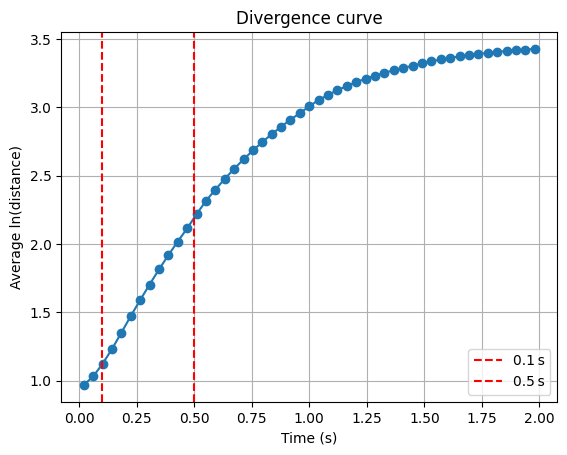

Lyapunov exponent (λ*) for axis x: 2.7300 1/s

--- Axis: z ---
DEBUG: fs = 100.0, 0.20*fs = 20.0, int(0.20*fs) = 20, τ_max = 20
→ chosen τ = 8 samples (0.080 s)
dims   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
fnn%   : [1.    0.958 0.881 0.837 0.823 0.834 0.892 0.946 0.981 0.998 0.999 1.
 1.    1.    1.    1.    1.    1.    1.    1.   ]
→ chosen emb dim m = 6


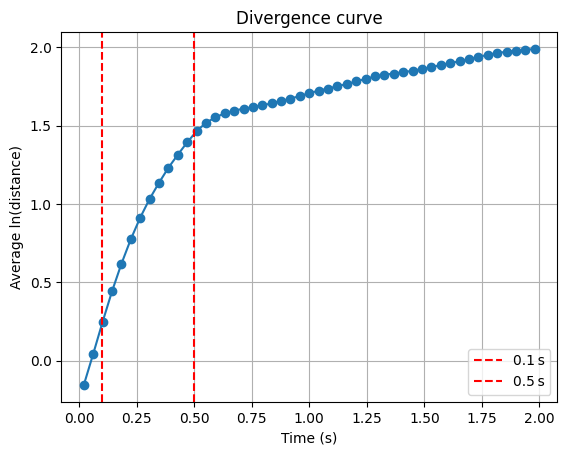

Lyapunov exponent (λ*) for axis z: 3.0693 1/s


In [89]:
def main():
    import numpy as np
    import matplotlib.pyplot as plt

    # 7.1) Load markers.nc and select COM
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = (cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13"
                 / "Pre.3" / "markers.nc")
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())

    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")

    time = com.coords["time"].values
    print("Time coordinates:", time[0], "to", time[-1])

    # Trim to roughly first 11000 samples (optional)
    start_time = time[247]
    end_time = time[11000]
    com = com.sel(time=slice(start_time, end_time))
    print("Selected COM shape:", start_time, end_time, com.shape)

    # 7.2) Parameters
    max_lag = 50        # search AMI up to 50 samples
    bins = 64           # number of bins for AMI
    max_dim = 20        # test FNN% up to 20 dims
    Rtol = 0.15         # relative threshold for FNN
    Atol_frac = 0.15    # absolute threshold fraction for FNN
    fs = 100.0          # sampling frequency (Hz)
    max_time = 2.0     # max divergence time (s)

    # # 7.3) Optional: Histogram + KDE of ML (x) axis (preprocessed)
    # ts_x = com.sel(axis="x").values.ravel()
    # ts_x = preprocess_signal(ts_x, fs, do_zscore=False)

    # plt.figure(figsize=(6, 4))
    # plt.hist(ts_x, bins=50, density=True, edgecolor="k", alpha=0.6)
    # plt.xlabel("COM_x (mm)")
    # plt.ylabel("Probability density")
    # plt.title("Histogram of ML–COM (preprocessed)")
    # plt.grid(True)
    # plt.show()

    # from scipy.stats import gaussian_kde
    # kde = gaussian_kde(ts_x)
    # xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    # plt.figure(figsize=(6, 4))
    # plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor="k", label="Hist")
    # plt.plot(xs, kde(xs), "r-", lw=2, label="KDE")
    # plt.xlabel("COM_x (mm)")
    # plt.ylabel("Probability density")
    # plt.title("Histogram + KDE of ML–COM (preprocessed)")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    # # 7.4) Optional: Scatter (x(t), x(t+τ)) for a few τ
    # ts_raw = com.sel(axis="x").values.ravel()
    # ts_raw = preprocess_signal(ts_raw, fs)
    # for tau in [10, 20, 40, 50, 100]:
    #     if tau < len(ts_raw):
    #         x1 = ts_raw[:-tau]
    #         x2 = ts_raw[tau:]
    #         plt.figure(figsize=(5, 5))
    #         plt.scatter(x1, x2, s=2, alpha=0.3)
    #         plt.xlabel("x(t)")
    #         plt.ylabel(f"x(t+{tau})")
    #         plt.title(f"Scatter: (x(t), x(t+{tau})), τ={tau} samples")
    #         plt.grid(True)
    #         plt.show()

    # 7.5) Process each axis: "x" (ML) and "z" (vertical)
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 7.5.1) Preprocess (detrend + low-pass + band-pass)
        ts_p = preprocess_signal(ts, fs, do_zscore=False)

                
        # 2) Pick lag exactly (eyeball the AMI curve, or force tau=round(0.1*fs)=10 if you think τ=1 is bogus)
        lag = optimal_lag(ts_p, fs=fs, max_lag=max_lag, bins=bins)
        print(f"→ chosen τ = {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN just to confirm embedding dimension
        dims, fnn_perc = compute_fnn_percentage(ts_p, lag, max_dim=max_dim,
                                                Rtol=Rtol, Atol_frac=Atol_frac)
        print("dims   :", dims)
        print("fnn%   :", np.round(fnn_perc, 3))
        m = optimal_embedding_dimension(ts_p, lag, max_dim=max_dim,
                                        Rtol=Rtol, Atol_frac=Atol_frac)
        print(f"→ chosen emb dim m = {m}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=m, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")



if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre.3\markers.nc
File exists?:              True
Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 13.55 121.07999999999998 (3, 10754)


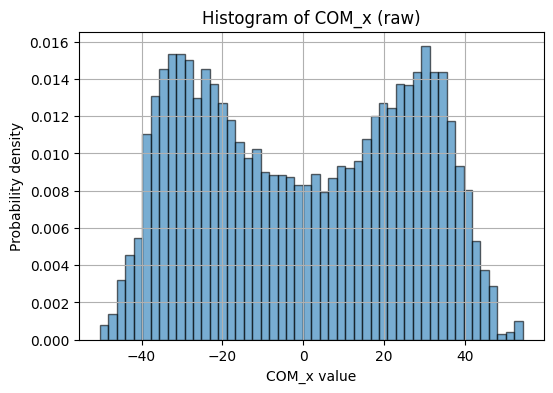

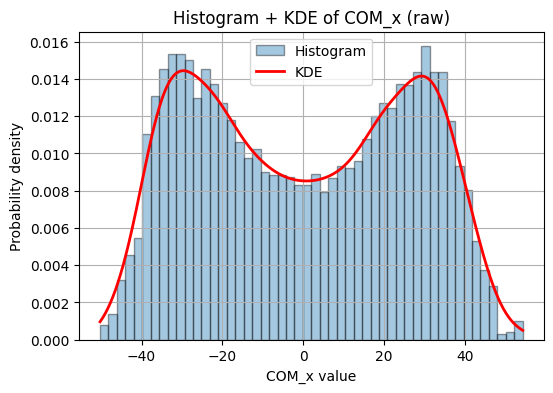

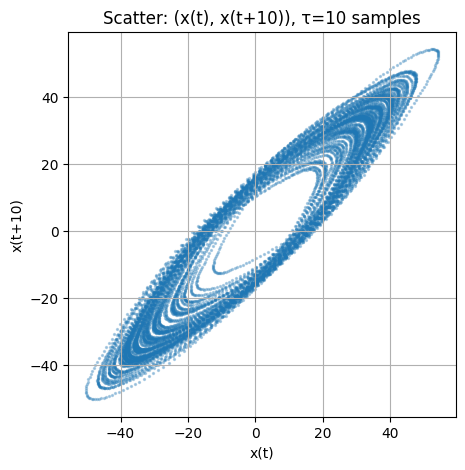

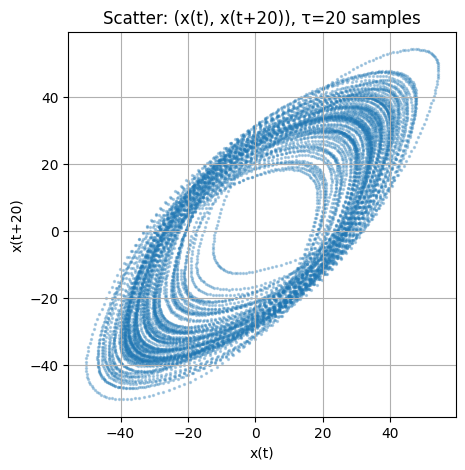

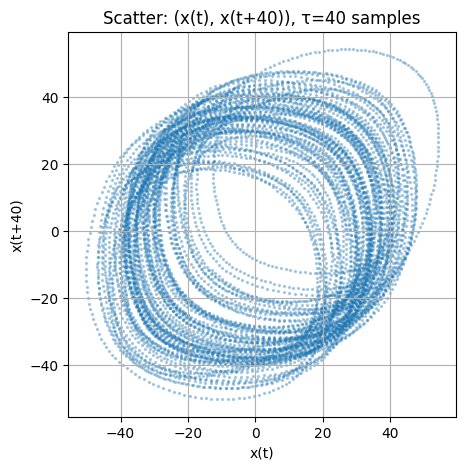

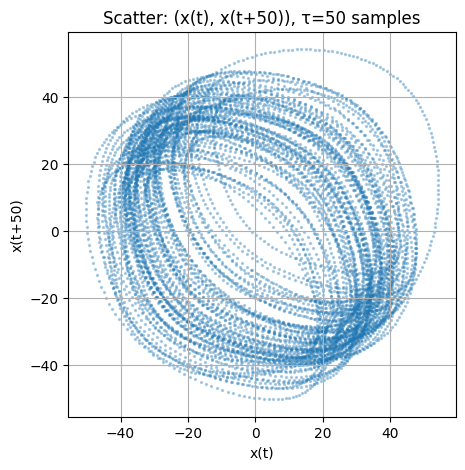

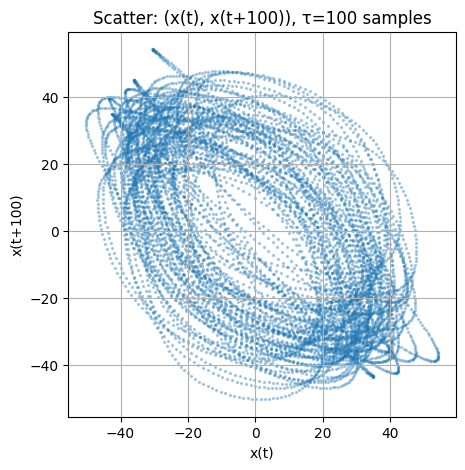


--- Axis: x ---


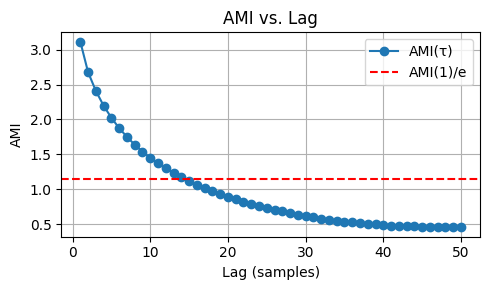

Optimal lag (τ) for axis x: 15 samples (0.150 s)


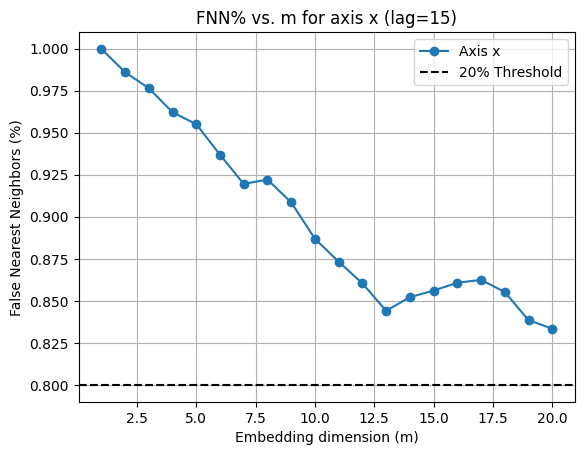

Optimal embedding dimension (m) for axis x: 13


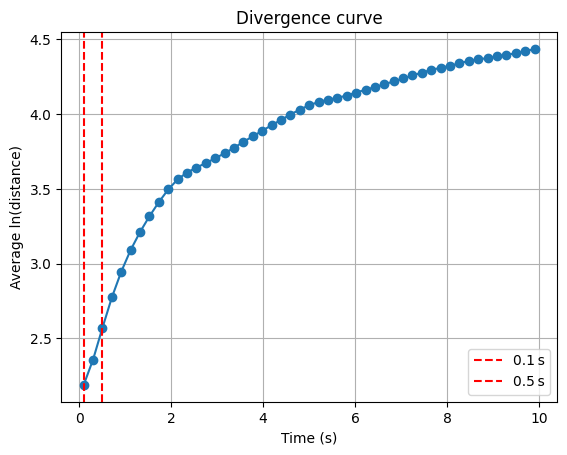

Lyapunov exponent (λ*) for axis x: 0.8336 1/s

--- Axis: z ---


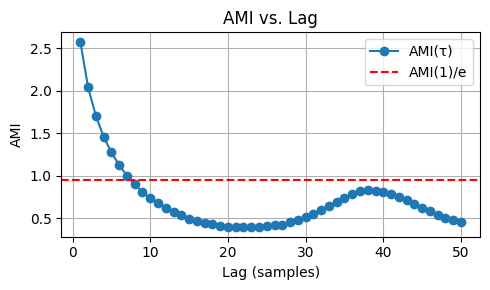

Optimal lag (τ) for axis z: 8 samples (0.080 s)


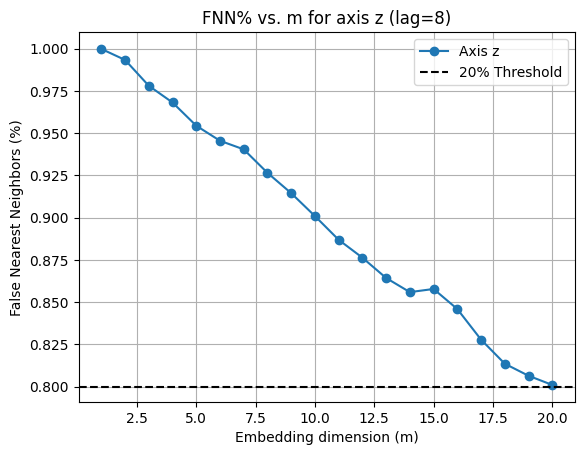

Optimal embedding dimension (m) for axis z: 15


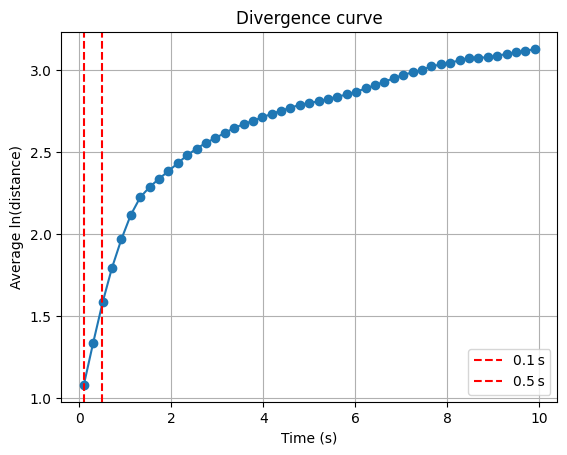

Lyapunov exponent (λ*) for axis z: 1.2653 1/s


In [94]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[247]
    end_time = time[11000]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre.3\markers.nc
File exists?:              True
Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 124.99999999999999 288.34999999999997 (3, 16336)


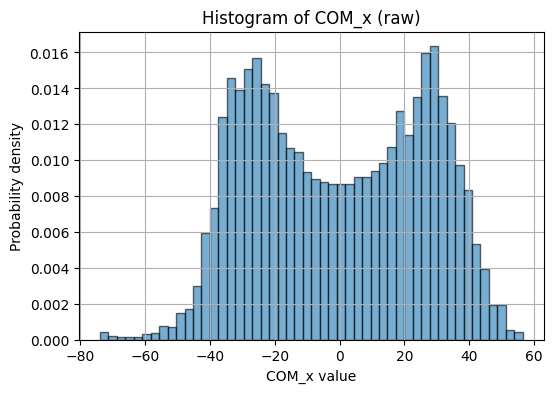

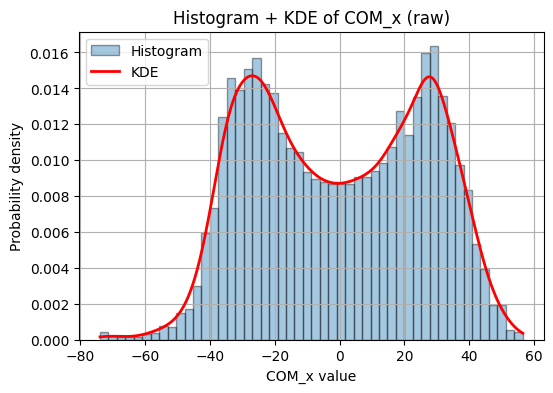

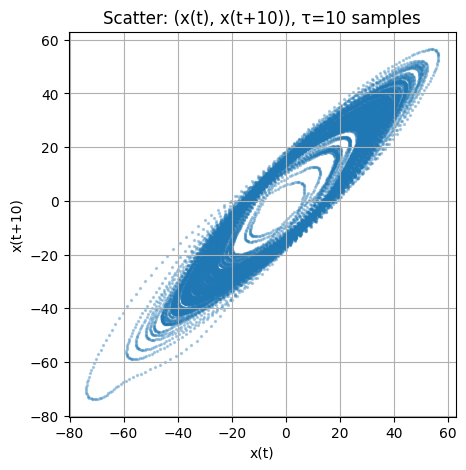

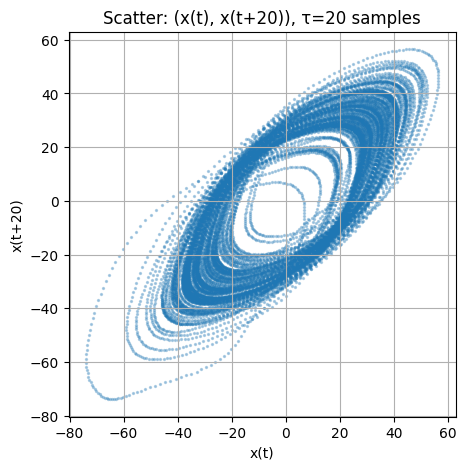

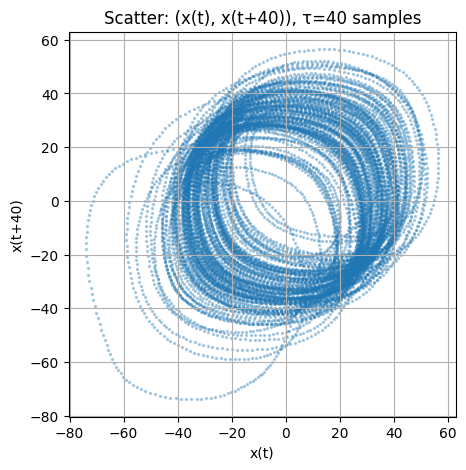

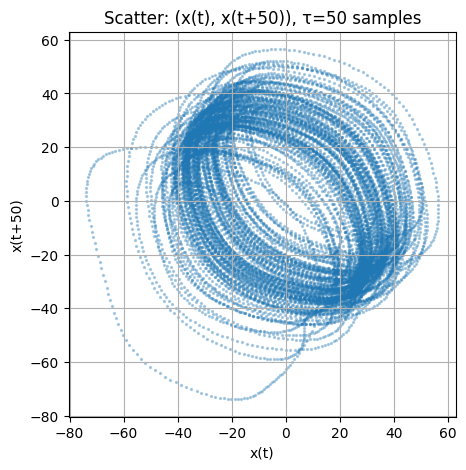

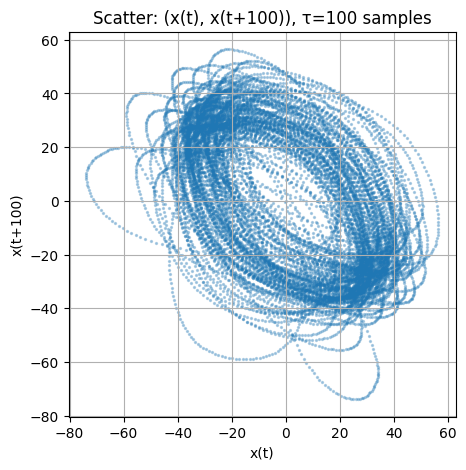


--- Axis: x ---


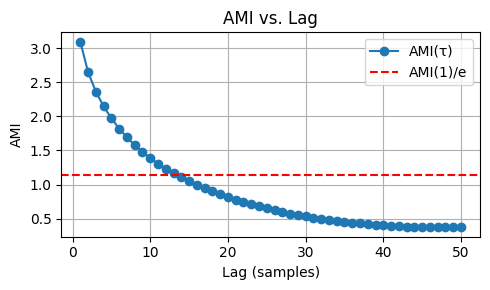

Optimal lag (τ) for axis x: 14 samples (0.140 s)


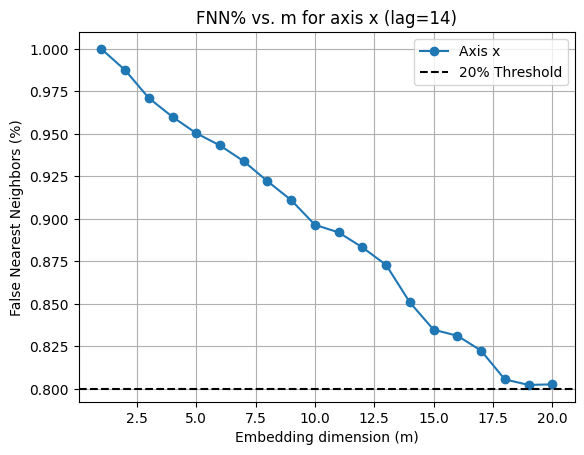

Optimal embedding dimension (m) for axis x: 18


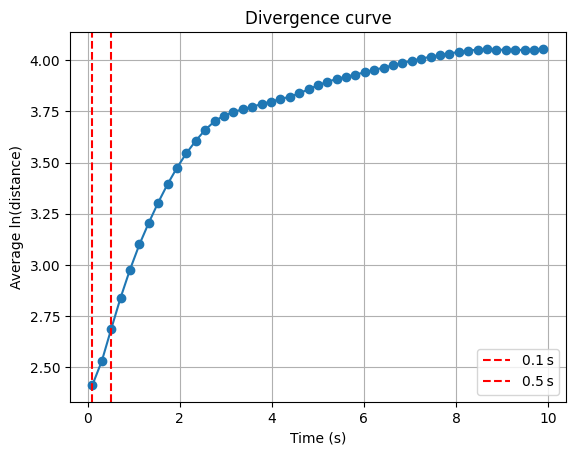

Lyapunov exponent (λ*) for axis x: 0.5741 1/s

--- Axis: z ---


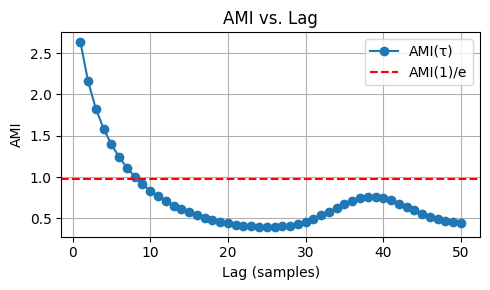

Optimal lag (τ) for axis z: 9 samples (0.090 s)


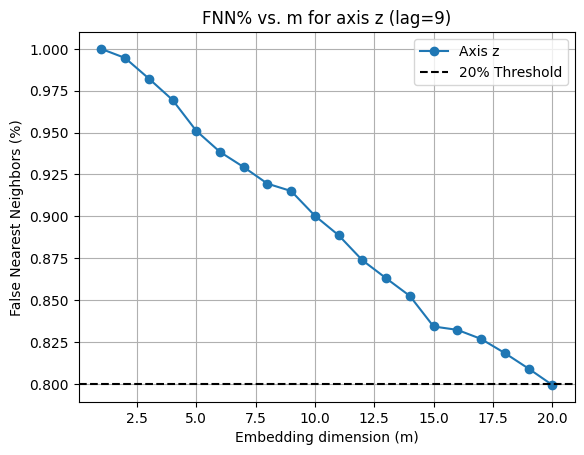

Optimal embedding dimension (m) for axis z: 15


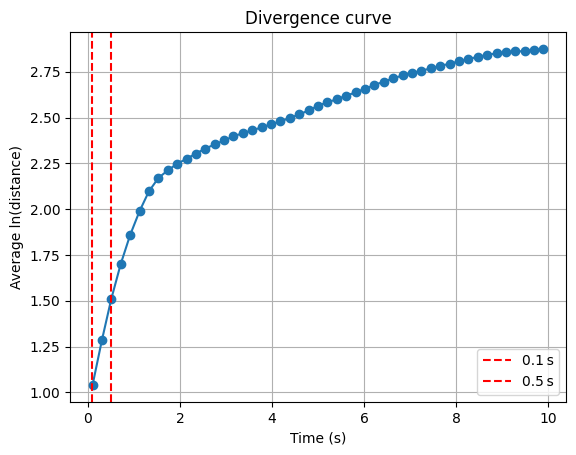

Lyapunov exponent (λ*) for axis z: 1.2040 1/s


In [95]:
def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[11392]
    end_time = time[-1]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_13\Pre.3\markers.nc
File exists?:              True
Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 24.49 121.07999999999998 (3, 9660)


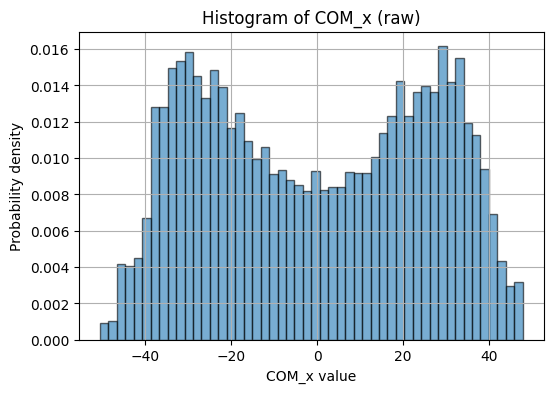

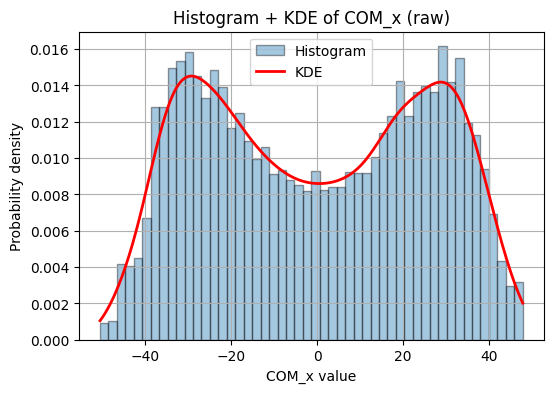

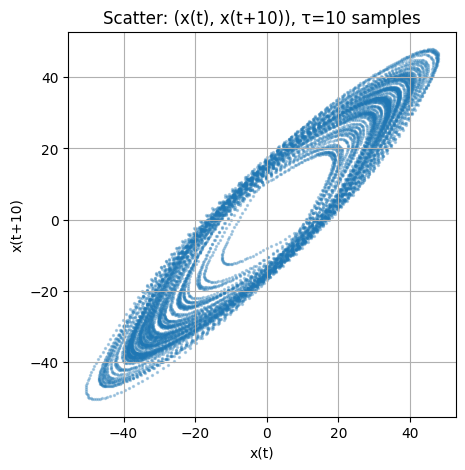

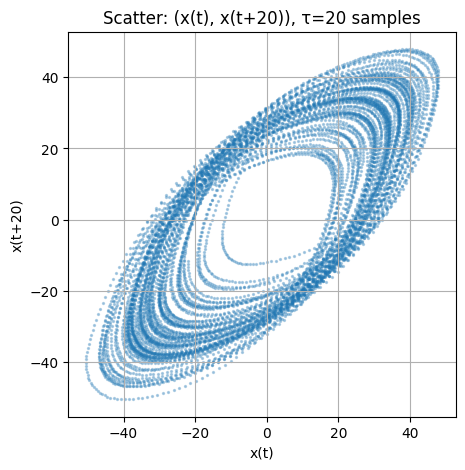

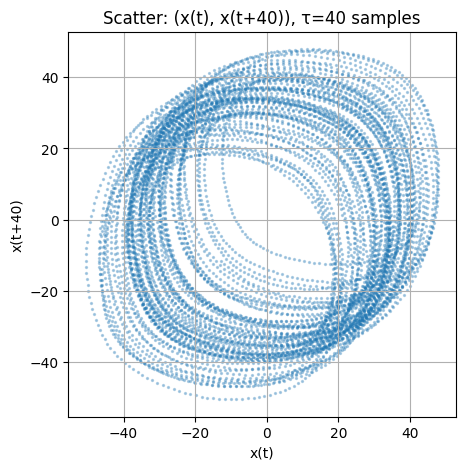

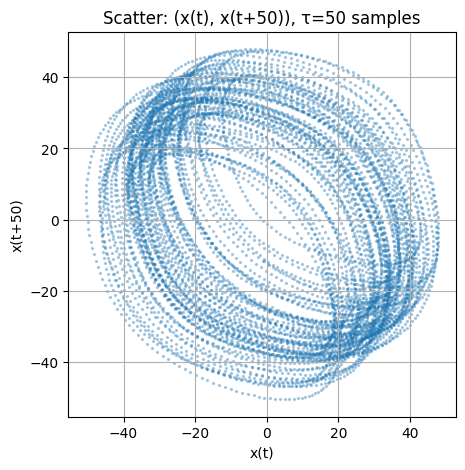

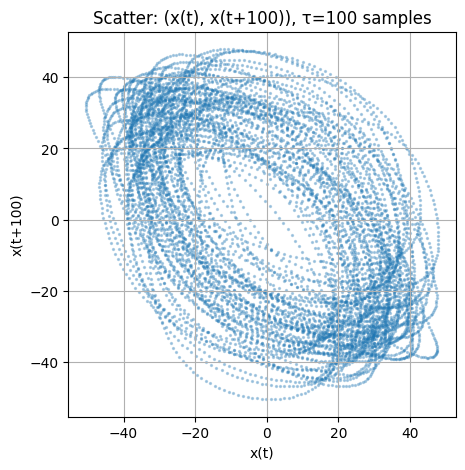


--- Axis: x ---


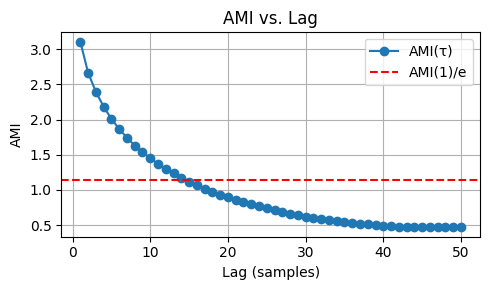

Optimal lag (τ) for axis x: 15 samples (0.150 s)


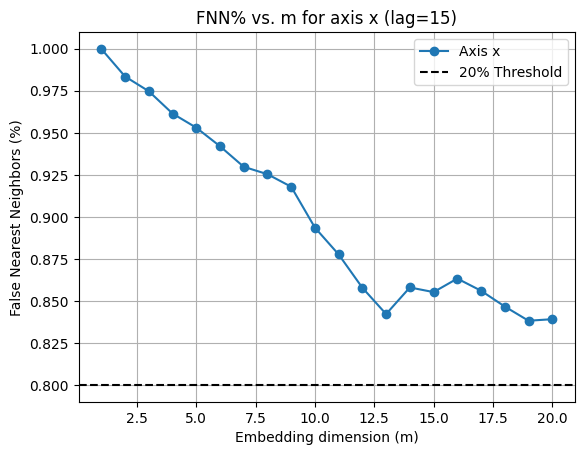

Optimal embedding dimension (m) for axis x: 13


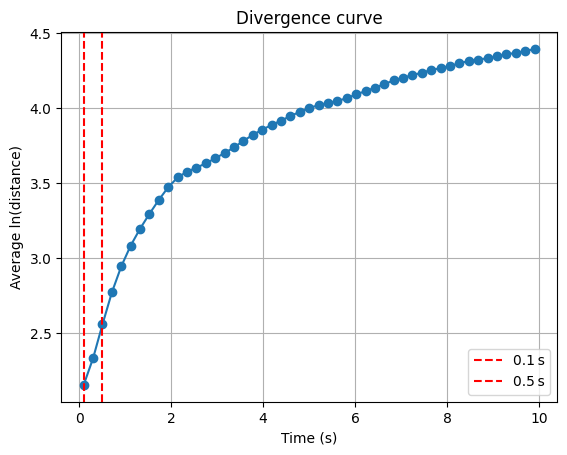

Lyapunov exponent (λ*) for axis x: 0.8724 1/s

--- Axis: z ---


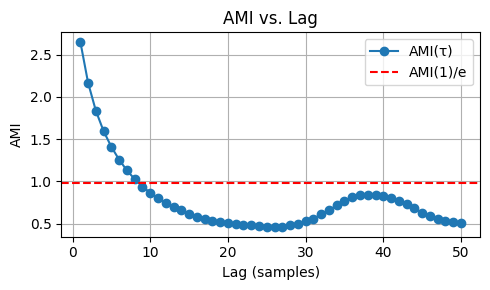

Optimal lag (τ) for axis z: 9 samples (0.090 s)


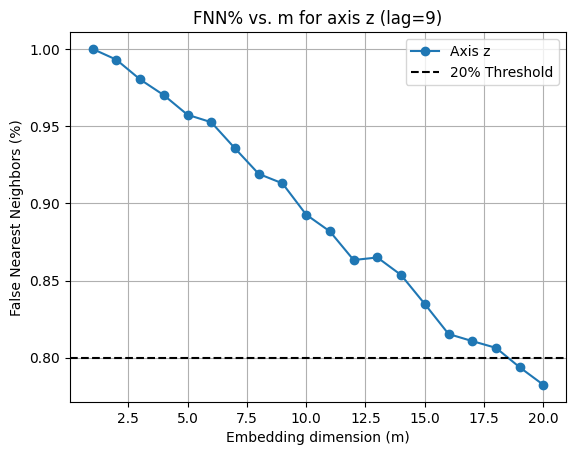

Optimal embedding dimension (m) for axis z: 12


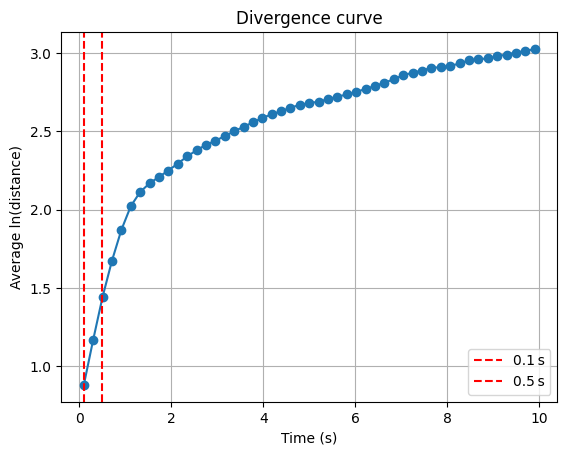

Lyapunov exponent (λ*) for axis z: 1.4188 1/s


In [ ]:


def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[1341]
    end_time = time[11000]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

Lyapunov patient 14

In [101]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt


# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(ts: np.ndarray,
                   fs: float = 100.0,
                   low_bp: float = 0.1,
                   high_bp: float = 5.0,
                   low_lp: float = 10.0,
                   do_zscore: bool = False) -> np.ndarray:
    """
    Preprocess a mediolateral COM (in mm) time series.
    
    Steps:
      1) Remove linear trend (detrend).
      2) Apply a gentle low-pass at `low_lp` Hz to remove >10 Hz noise.
      3) Apply a band-pass between `low_bp`–`high_bp` Hz to keep step frequency.
      4) Optionally zero-mean & unit-variance (z-score).
    
    Inputs:
      ts      : 1D np.ndarray of COM_x values in millimeters.
      fs      : Sampling frequency (default 100 Hz).
      low_bp  : Lower cutoff for band-pass (default 0.1 Hz).
      high_bp : Upper cutoff for band-pass (default 5.0 Hz).
      low_lp  : Cutoff for low-pass (default 10.0 Hz).
      do_zscore : If True, z-score the final output.
    
    Returns:
      ts_out  : Preprocessed 1D array, same length as input.
    """
    # 1) Detrend
    ts_dt = detrend(ts)

    # 2) Gentle low-pass at low_lp Hz
    nyq = fs / 2.0
    b_lp, a_lp = butter(N=4, Wn=(low_lp/nyq), btype='low')
    ts_lp = filtfilt(b_lp, a_lp, ts_dt)

    # 3) Band-pass from low_bp to high_bp Hz
    b_bp, a_bp = butter(N=4, Wn=[low_bp/nyq, high_bp/nyq], btype='bandpass')
    ts_bp = filtfilt(b_bp, a_bp, ts_lp)

    # 4) (Optional) Z-score
    if do_zscore:
        ts_out = (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)
    else:
        ts_out = ts_bp

    return ts_out



# 2) Average Mutual Information with quantile bins
def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 64) -> float:
    """
    Compute AMI I(lag) between x(t) and x(t+lag) using equal‐occupancy bins.
    """
    edges = np.quantile(ts, np.linspace(0, 1, bins+1))
    x, y = ts[:-lag], ts[lag:]
    hist2d, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pxy = hist2d / np.sum(hist2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px[:, None] * py[None, :])[mask]))


def optimal_lag(ts: np.ndarray,
                fs: float = 100.0,
                max_lag: int = 50,
                bins: int = 64) -> int:
    """
    Find a single, adaptive delay τ for embedding via Average Mutual Information (AMI),
    suitable for both healthy and Parkinson's gait.

    Steps:
      1) Compute AMI(τ) for τ = 1…max_lag.
      2) Plot AMI vs. τ with the AMI(1)/e threshold for visual check.
      3) Search for the first “filtered mild local minimum,” but only up to τ ≤ 0.20·fs:
           • AMI[i] ≤ AMI[i−1]  AND  AMI[i] ≤ AMI[i+1]
           • AND (AMI[i] ≤ 0.80·AMI(1)   OR   AMI[i] ≤ 0.90·AMI[i−1])
        (This prevents the algorithm from choosing a very small τ unless AMI has already
         dropped by ≥ 20% of AMI(1).)
      4) If no acceptable knee appears by τ = ⌊0.20·fs⌋, fallback to the first τ ≤ ⌊0.20·fs⌋
         where AMI(τ) ≤ AMI(1)/e.
      5) If nothing qualifies by τ = ⌊0.20·fs⌋, return the global‐minimum lag over 1…max_lag.
    """
    # 1) Compute AMI for τ = 1…max_lag
    ami_vals = [average_mutual_information(ts, lag, bins)
                for lag in range(1, max_lag + 1)]
    lags = np.arange(1, max_lag + 1)
    ami1 = ami_vals[0]

    # 2) Plot AMI vs. τ (optional, but good to inspect)
    plt.figure(figsize=(5, 3))
    plt.plot(lags, ami_vals, '-o', label='AMI(τ)')
    plt.axhline(ami1 / np.e, color='r', linestyle='--', label='AMI(1)/e')
    plt.xlabel('Lag (samples)')
    plt.ylabel('AMI')
    plt.title('AMI vs. Lag')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Define a hard cutoff at τ_max = floor(0.20 * fs).  At 100 Hz, that is τ_max = 20.
    τ_max = min(max_lag, int(0.20 * fs))  # e.g. 20 if fs=100

    # If τ_max < 3 we can’t form a “local minimum” search, so just skip to fallback
    if τ_max < 3:
        return 1

    # 4) Look for the first “filtered mild local minimum” among τ = 2 … (τ_max - 1)
    #    (Indices i = 1 … (τ_max - 2) correspond to τ = i+1 = 2 … (τ_max-1))
    for i in range(1, τ_max - 1):  # i+1 ranges from 2 to τ_max-1
        if ami_vals[i] <= ami_vals[i - 1] and ami_vals[i] <= ami_vals[i + 1]:
            τ_candidate = i + 1  # because ami_vals[0] is τ=1
            # 4a) If τ_candidate is small (<5), only accept it if AMI has fallen by ≥20%
            if τ_candidate < 5:
                if ami_vals[i] <= 0.80 * ami1:
                    return τ_candidate
                else:
                    # Too shallow a drop at a very small τ—ignore it
                    continue
            # 4b) If τ_candidate ≥ 5, accept it unconditionally
            return τ_candidate

    # 5) Fallback #1: first τ ≤ τ_max where AMI(τ) ≤ AMI(1)/e
    threshold = ami1 / np.e
    for i in range(τ_max):  # i corresponds to τ = i+1
        if ami_vals[i] <= threshold:
            return i + 1

    # 6) Fallback #2: global minimum over τ = 1…max_lag
    return int(np.argmin(ami_vals) + 1)


def compute_fnn_percentage(ts: np.ndarray, lag: int,
                           max_dim: int = 15, rtol: float = 0.15):
    """
    Compute % of false nearest neighbors for embedding dims from 1 to max_dim.
    """
    N = len(ts)
    dims = np.arange(1, max_dim + 1)
    fnn_perc = np.zeros_like(dims, dtype=float)

    for idx, m in enumerate(dims):
        M = N - m * lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break
        # Build m-dimensional delay vectors
        embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(m)]).T
        false = total = 0
        for i in range(M):
            # compute distances to all other points
            dists = np.linalg.norm(embedded - embedded[i], axis=1)
            dists[i] = np.inf
            # exclude temporally too-close points
            dists[max(0, i - m * lag) : i + m * lag] = np.inf
            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue
            d_extra = abs(ts[i + m * lag] - ts[j + m * lag])
            if d_extra / dists[j] > rtol:
                false += 1
            total += 1
        fnn_perc[idx] = false / total if total else np.nan

    return dims, fnn_perc


# 5) Optimal embedding dimension by “elbow” / max second‐difference
def optimal_embedding_dimension(ts: np.ndarray,
                                lag: int,
                                max_dim: int = 15,
                                rtol: float = 0.15) -> int:
    """
    Choose embedding dimension m by finding the 'elbow' in the FNN% curve:
      1) Compute FNN% for m = 1…max_dim
      2) Take the second discrete difference of the fnn% array
      3) Return the dimension m corresponding to the index of maximal |second_difference|

    This follows the theoretical idea that the largest curvature (elbow) in the FNN% vs. m
    plot is the best embedding dimension when no fixed threshold is applied.
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)

    # If there's only one dimension or fnn cannot be computed, just return max_dim
    if len(dims) < 3 or np.all(np.isnan(fnn)):
        return max_dim

    # Compute second discrete difference of the FNN% curve
    # second_diff[i] = fnn[i] - 2*fnn[i+1] + fnn[i+2], where i = 0..(len(fnn)-3)
    second_diff = np.diff(fnn, n=2)

    # If all second_diff are NaN or zero, fallback to max_dim
    if np.all(np.isnan(second_diff)) or np.allclose(second_diff, 0, equal_nan=True):
        return max_dim

    # Find the index of maximum absolute curvature
    # Since second_diff is length (max_dim - 2), its index i corresponds to m = i + 2
    i_elbow = int(np.nanargmax(np.abs(second_diff)))
    m_elbow = i_elbow + 2

    # Ensure we do not exceed max_dim
    if m_elbow < 1:
        return 1
    if m_elbow > max_dim:
        return max_dim
    return m_elbow




# 6) Rosenstein's λ_max with linear‐region fit (0.1–0.5 s)
def compute_lyapunov_exponent(ts: np.ndarray, emb_dim: int, lag: int,
                              fs: float = 100.0, max_time: float = 5.0) -> float:
    """
    Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors.
    Fit ⟨ln d(t)⟩ vs. t over 0.1–0.5 s.
    """
    N = len(ts)
    M = N - (emb_dim - 1) * lag
    if M <= 0:
        return np.nan

    embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i - min_sep) : i + min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i + k] - embedded[j + k])
            if d > 0:
                divergence.append((k / fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:, 0], data[:, 1]

    # Bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins) - 1):
        mask = (times >= bins[b]) & (times < bins[b + 1])
        if mask.any():
            centers.append((bins[b] + bins[b + 1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # Plot divergence curve for inspection
    plt.figure()
    plt.plot(centers, means, 'o-')
    plt.axvline(0.1, color='r', linestyle='--', label='0.1 s')
    plt.axvline(1.30, color='r', linestyle='--', label='1.3 s')
    plt.xlabel('Time (s)')
    plt.ylabel('Average ln(distance)')
    plt.title('Divergence curve')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Fit only over 0.1–0.5 s
    fit_mask = (centers >= 0.1) & (centers <= 1.3)
    if fit_mask.sum() < 2:
        return np.nan

    slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    return slope


Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_14\Pre.3\markers.nc
File exists?:              True
Time coordinates: 0.0 to 255.72
Selected COM shape: 0.46 110.0 (3, 10955)


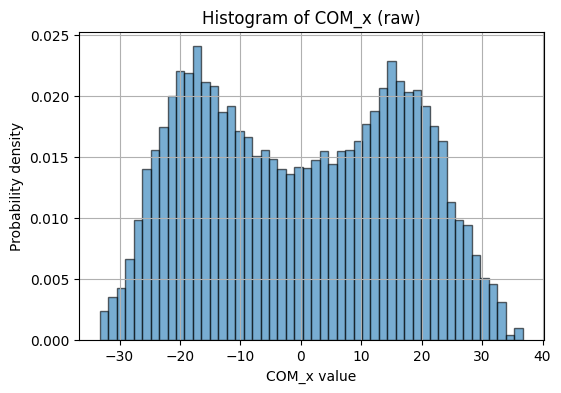

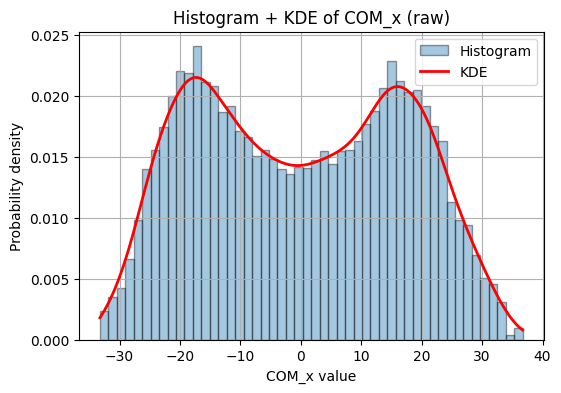

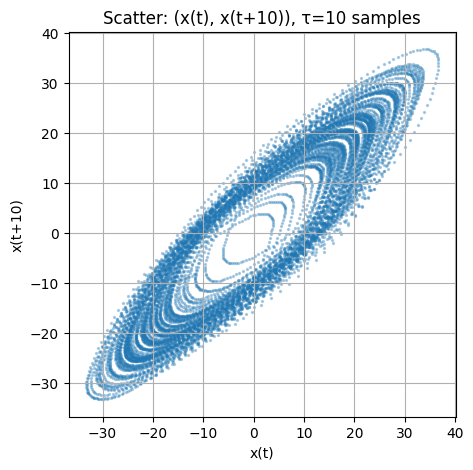

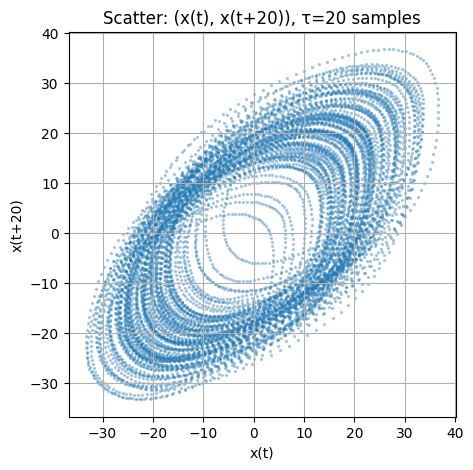

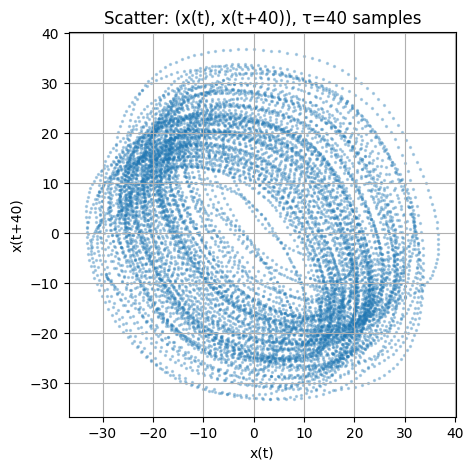

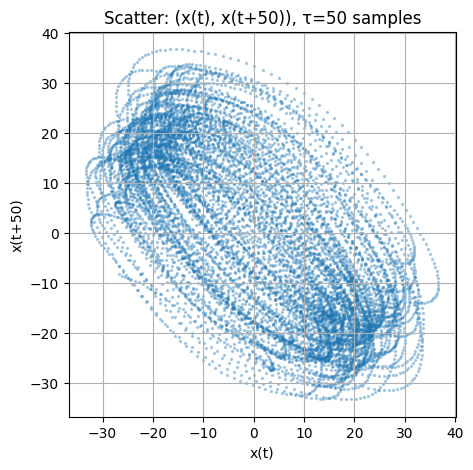

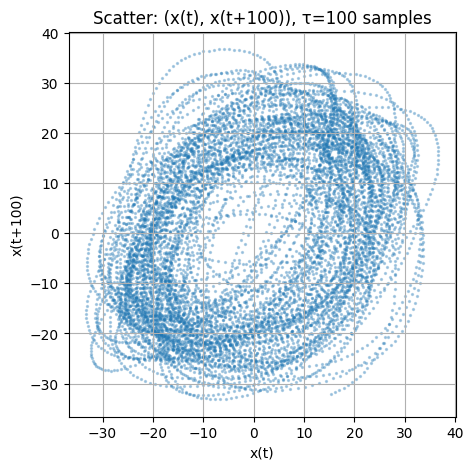


--- Axis: x ---


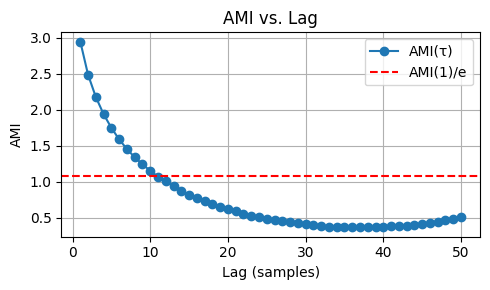

Optimal lag (τ) for axis x: 11 samples (0.110 s)


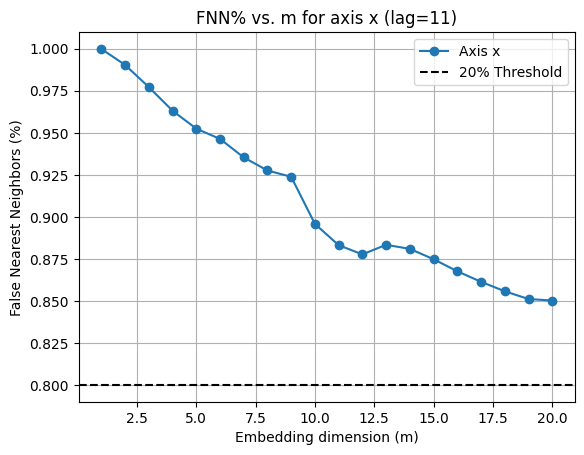

Optimal embedding dimension (m) for axis x: 9


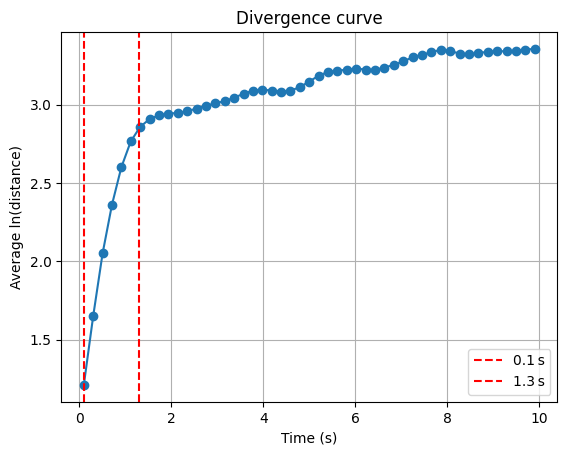

Lyapunov exponent (λ*) for axis x: 1.5310 1/s

--- Axis: z ---


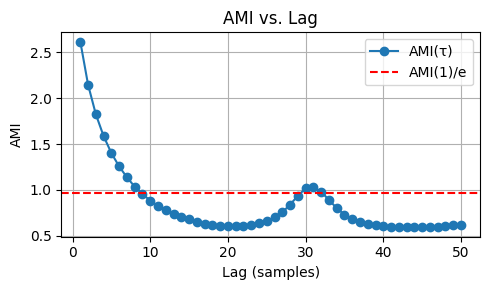

Optimal lag (τ) for axis z: 9 samples (0.090 s)


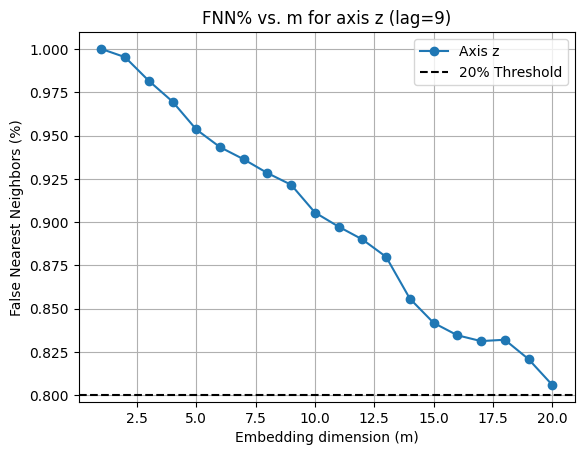

Optimal embedding dimension (m) for axis z: 13


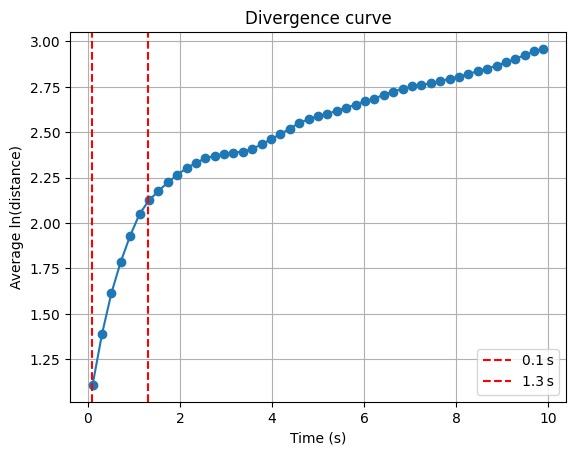

Lyapunov exponent (λ*) for axis z: 0.9110 1/s


In [102]:


def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_14" /"Pre.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[46]
    end_time = time[11000]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\PBT\Young\Cereneo_SR_14\Pre.3\markers.nc
File exists?:              True
Time coordinates: 0.0 to 255.72
Selected COM shape: 20.6 122.0 (3, 10141)


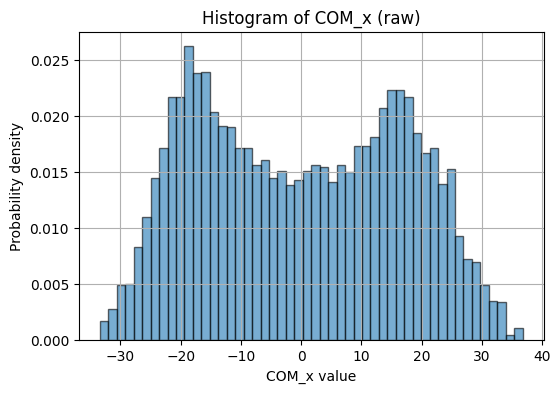

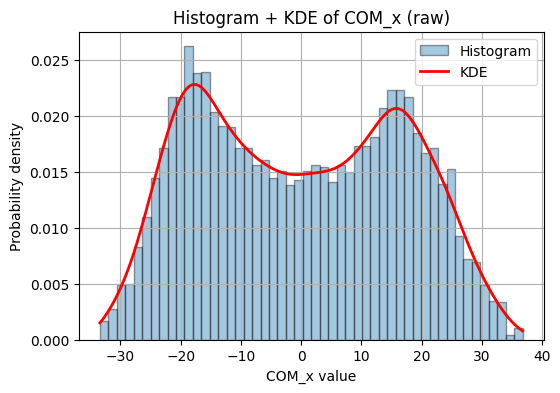

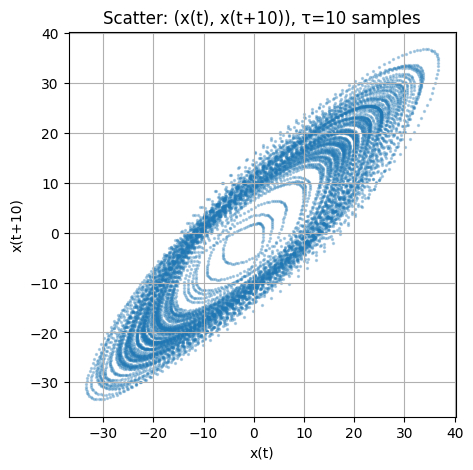

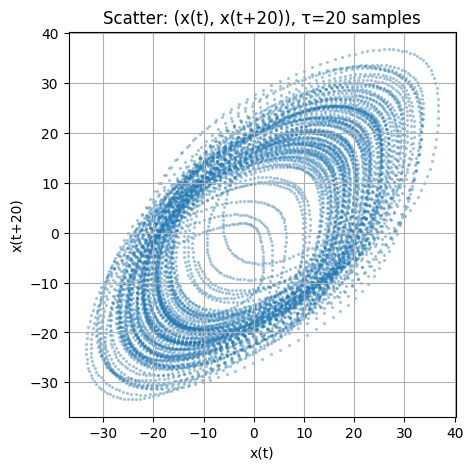

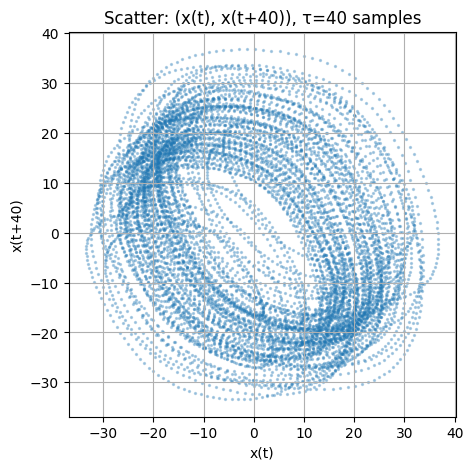

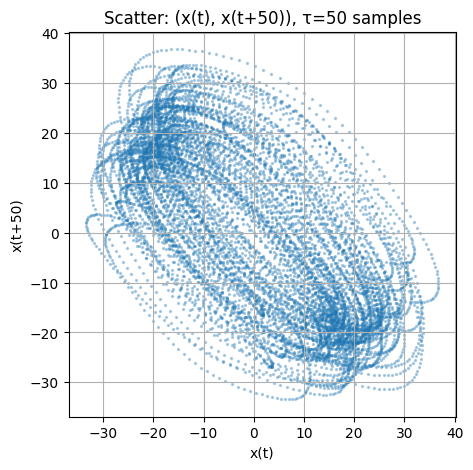

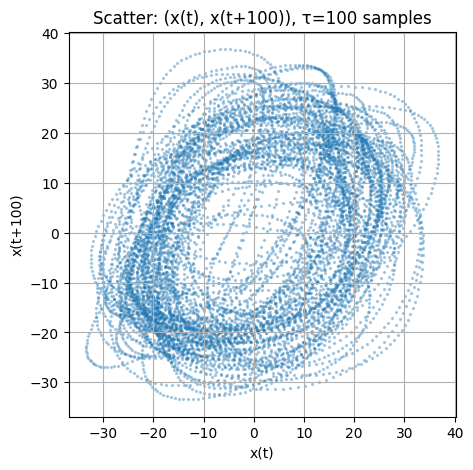


--- Axis: x ---


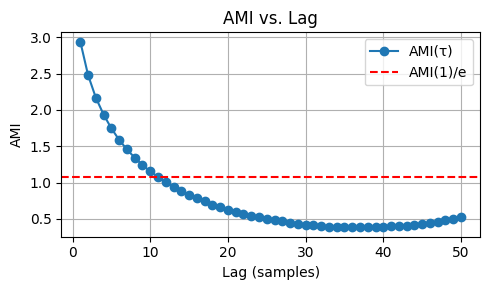

Optimal lag (τ) for axis x: 11 samples (0.110 s)


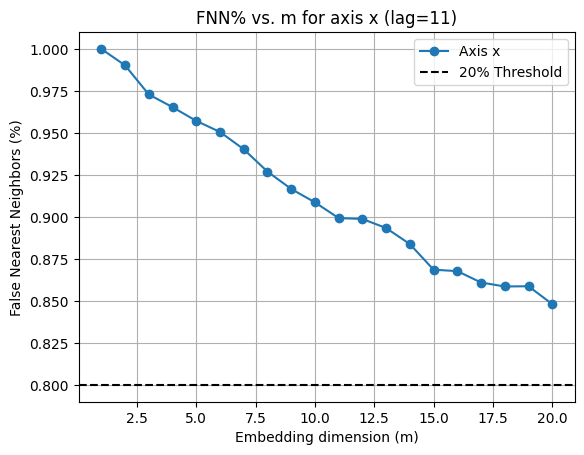

Optimal embedding dimension (m) for axis x: 15


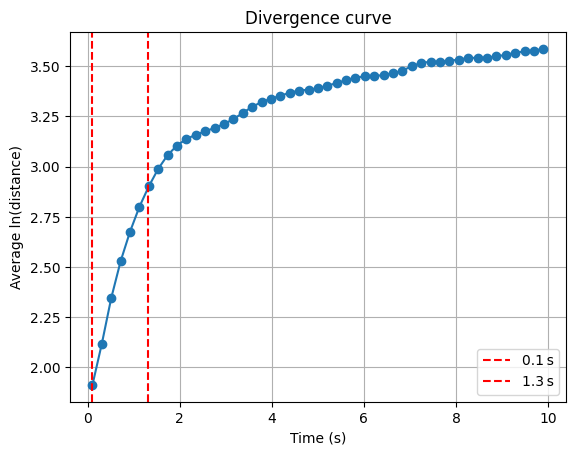

Lyapunov exponent (λ*) for axis x: 0.8806 1/s

--- Axis: z ---


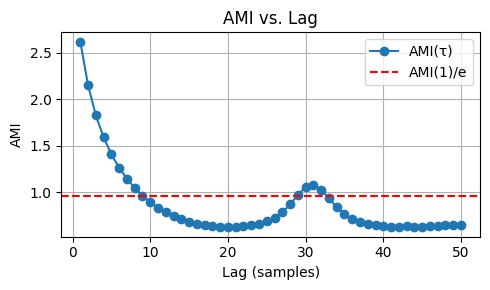

Optimal lag (τ) for axis z: 10 samples (0.100 s)


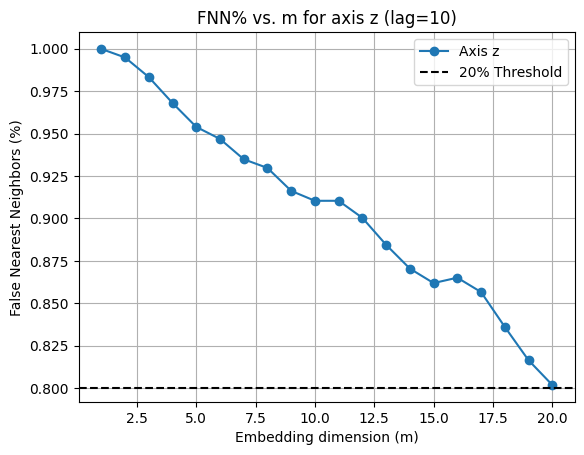

Optimal embedding dimension (m) for axis z: 17


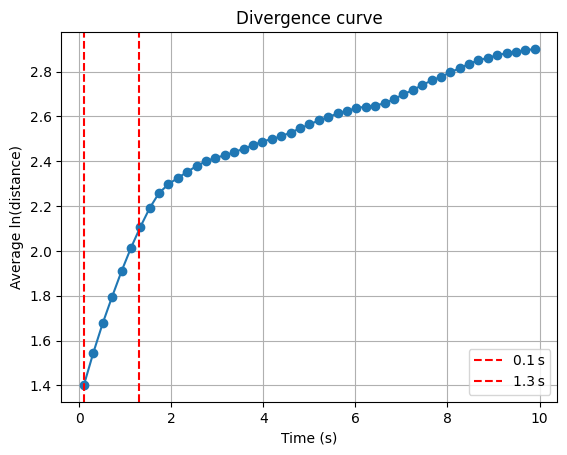

Lyapunov exponent (λ*) for axis z: 0.5969 1/s


In [105]:


def main():
    from pathlib import Path
    import matplotlib.pyplot as plt
    cwd = Path.cwd()
    print("Current working directory:", cwd)
    file_path = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_14" /"Pre.3"/ "markers.nc"
    print("Resolved file path:       ", file_path.resolve())
    print("File exists?:             ", file_path.exists())
    # load and select COM
    ds = xr.open_dataset(file_path)
    da = ds["markers"] if "markers" in ds else ds
    com = da.sel(channel="COM")
    time = com.coords["time"].values  
    print("Time coordinates:", time[0], "to", time[-1])
    start_time = time[2060]
    end_time = time[12200]
    com = com.sel(time=slice(start_time, end_time))  # select first 50 time points
    print("Selected COM shape:", start_time, end_time, com.shape)

    # ------------- Parameters -------------
    max_lag = 50        # Search AMI up to 50 samples (0.50 s)
    bins = 64
    max_dim = 20        # Search FNN% up to 20 dimensions
    rtol = 0.10
    fnn_threshold = 0.80
    fs = 100.0
    max_time = 10.0     # Max evolution time for divergence (s)
    import numpy as np
    import matplotlib.pyplot as plt

    # Assume ts_raw is your raw (detrended/unfiltered) COM_x array of length N:
    ts_x= com.sel(axis='x').values.ravel()
    ts_x=preprocess_signal(ts_x, fs)  # Preprocess the signal
    # 1a) Simple histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

    # 1b) Optionally, a smoothed kernel‐density estimate (if you have seaborn, or use scipy)
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(ts_x)              # fit a Gaussian kernel density
    xs = np.linspace(ts_x.min(), ts_x.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_x, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs, kde(xs), 'r-', lw=2, label='KDE')
    plt.xlabel('COM_x value')
    plt.ylabel('Probability density')
    plt.title('Histogram + KDE of COM_x (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ts_raw is your raw (detrended but unfiltered) COM_x array
    ts_raw = com.sel(axis='x').values.ravel()
    ts_raw = preprocess_signal(ts_raw, fs)  # Preprocess the signal
    for tau in [10, 20,40,50,100]:  # try a few small lags
        x1 = ts_raw[:-tau]   # x(t)
        x2 = ts_raw[tau:]    # x(t + tau)

        plt.figure(figsize=(5,5))
        plt.scatter(x1, x2, s=2, alpha=0.3)
        plt.xlabel(f'x(t)')
        plt.ylabel(f'x(t+{tau})')
        plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
        plt.grid(True)
        plt.show()



    # ------------- Process each axis separately -------------
    for axis in ["x", "z"]:
        print(f"\n--- Axis: {axis} ---")
        ts = com.sel(axis=axis).values.ravel()

        # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
        ts = preprocess_signal(ts, fs)

        # 2) Find axis-specific optimal lag via AMI
        lag = optimal_lag(ts, max_lag=max_lag, bins=bins)
        print(f"Optimal lag (τ) for axis {axis}: {lag} samples ({lag/fs:.3f} s)")

        # 3) Compute FNN% up to max_dim
        dims, fnn_perc = compute_fnn_percentage(ts, lag, max_dim=max_dim, rtol=rtol)

        # 4) Plot FNN% vs. embedding dimension
        plt.figure()
        plt.plot(dims, fnn_perc, "-o", label=f"Axis {axis}")
        plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
        plt.xlabel("Embedding dimension (m)")
        plt.ylabel("False Nearest Neighbors (%)")
        plt.title(f"FNN% vs. m for axis {axis} (lag={lag})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # 5) Find axis-specific embedding dimension
        dim = optimal_embedding_dimension(
            ts, lag, max_dim=max_dim, rtol=rtol
        )
        print(f"Optimal embedding dimension (m) for axis {axis}: {dim}")

        # 6) Compute Lyapunov exponent for this axis
        lyap = compute_lyapunov_exponent(ts, emb_dim=dim, lag=lag, fs=fs, max_time=max_time)
        print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap:.4f} 1/s")


if __name__ == "__main__":
    main()